# Импорты

In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy
import os

# Вспомогательные функции

## Отображение изображения

In [15]:
def show_image(image: cv2.Mat) -> None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image_rgb)
    plt.axis("off")
    plt.show()

## Сохранение изображения

In [16]:
def save_image(path: str, image: cv2.Mat) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    cv2.imwrite(path, image)

## Поворот

In [17]:
def rotate(image: cv2.Mat, mask: cv2.Mat) -> tuple[cv2.Mat, cv2.Mat]:
    angle = numpy.random.randint(-180, 180)
    height, width = image.shape[:2]
    center = (width // 2, height // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    image_rotated = cv2.warpAffine(image, M, (width, height))
    mask_rotated = cv2.warpAffine(mask, M, (width, height))

    return image_rotated, mask_rotated

## Отражение

In [18]:
def flip(image: cv2.Mat, mask: cv2.Mat, flip_code: int) -> tuple[cv2.Mat, cv2.Mat]:
    img_flipped = cv2.flip(image, flip_code)
    mask_flipped = cv2.flip(mask, flip_code)

    return img_flipped, mask_flipped

## Вырезание кусочка

In [19]:
def crop(image: cv2.Mat, mask: cv2.Mat, crop_size: int = 100) -> tuple[cv2.Mat, cv2.Mat]:
    height, width = image.shape[:2]
    x = numpy.random.randint(0, width - crop_size)
    y = numpy.random.randint(0, height - crop_size)

    image_cropped = image[y:y+crop_size, x:x+crop_size]
    mask_cropped = mask[y:y+crop_size, x:x+crop_size]

    return image_cropped, mask_cropped


## Изменение цвета

In [20]:
def change_color(image: cv2.Mat, saturation: int = 30) -> cv2.Mat:
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hsv[:, :, 1] = cv2.add(hsv[:, :, 1], saturation)
    
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

## Размытие

In [21]:
def blur(image: cv2.Mat) -> cv2.Mat:
    return cv2.GaussianBlur(image, (7, 7), 1.4)

## Шум

In [22]:
def noise(image: cv2.Mat) -> cv2.Mat:
    noise = numpy.random.normal(0, 10, image.shape).astype(numpy.uint8)
    return cv2.add(image, noise)

# Загрузка изображения

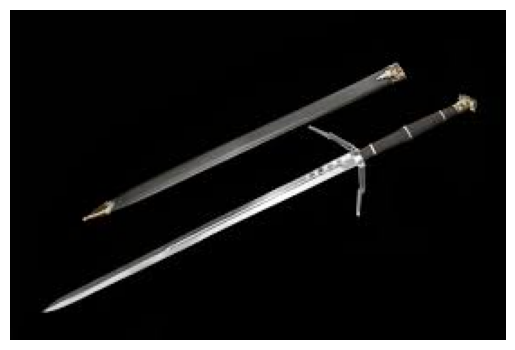

In [23]:
image = cv2.imread("image.jpg")
show_image(image)

# Создание маски

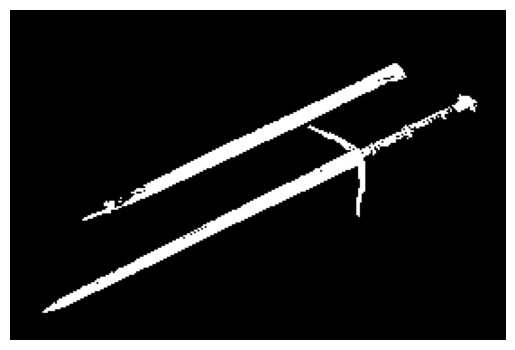

In [24]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

save_image("./mask.jpg", mask)
show_image(mask)

# Аугментация

In [25]:
N = 10

for i in range(N):
    image_rotated, mask_rotated = rotate(image, mask)
    save_image(f"augmentation/augmentation_{i}/rotate/image.jpg", image_rotated)
    save_image(f"augmentation/augmentation_{i}/rotate/mask.jpg", mask_rotated)

    for flip_code in [-1, 0, 1]:
        flipped_image, flipped_mask = flip(image_rotated, mask_rotated, flip_code)
        save_image(f"augmentation/augmentation_{i}/flip/{flip_code}/image.jpg", flipped_image)
        save_image(f"augmentation/augmentation_{i}/flip/{flip_code}/mask.jpg", flipped_mask)

    image_cropped, mask_cropped = crop(image, mask)
    save_image(f"augmentation/augmentation_{i}/crop/image.jpg", image_cropped)
    save_image(f"augmentation/augmentation_{i}/crop/mask.jpg", mask_cropped)

    image_with_new_colors = change_color(image)
    save_image(f"augmentation/augmentation_{i}/new_colors/image.jpg", image_with_new_colors)
    save_image(f"augmentation/augmentation_{i}/new_colors/mask.jpg", mask)

    image_blurred = blur(image)
    save_image(f"augmentation/augmentation_{i}/blur/image.jpg", image_blurred)
    save_image(f"augmentation/augmentation_{i}/blur/mask.jpg", mask)

    image_noised = noise(image)
    save_image(f"augmentation/augmentation_{i}/noise/image.jpg", image_noised)
    save_image(f"augmentation/augmentation_{i}/noise/mask.jpg", mask)